# Downscaling WS

In [1]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import os
import shutil
import csv
import pandas as pd
import torch_dl4ds as dds
import torch as pt

In [2]:
!python --version
#Should be Python 3.11.13

Python 3.11.13


In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [4]:
uwrf_train

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB ...
    V10        (time, y, x) float32 155MB ...
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [5]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [6]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'


for ds in nam_list:

            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'

In [7]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

# Main training code



Here you can run multiple trainings trying different combinations of predictor variables and architectures.

Running model with backbone=resnet, filters=8, blocks=8, epochs=50


Epoch 1/50, Train Loss: 0.7016, Val Loss: 0.4678


Epoch 2/50, Train Loss: 0.3326, Val Loss: 0.2080


Epoch 3/50, Train Loss: 0.2055, Val Loss: 0.1659


Epoch 4/50, Train Loss: 0.1839, Val Loss: 0.1540


...

Epoch 46/50, Train Loss: 0.1056, Val Loss: 0.0721


Epoch 47/50, Train Loss: 0.1052, Val Loss: 0.0736


Epoch 48/50, Train Loss: 0.1055, Val Loss: 0.0801


Epoch 49/50, Train Loss: 0.1091, Val Loss: 0.0728


Epoch 50/50, Train Loss: 0.1047, Val Loss: 0.0706
Total runtime: 4h 4m 40s
Plot saved to: /home/gvaillant1/downscaling/pretrained-models/WS/WS-Other-Models/learning_curve.png


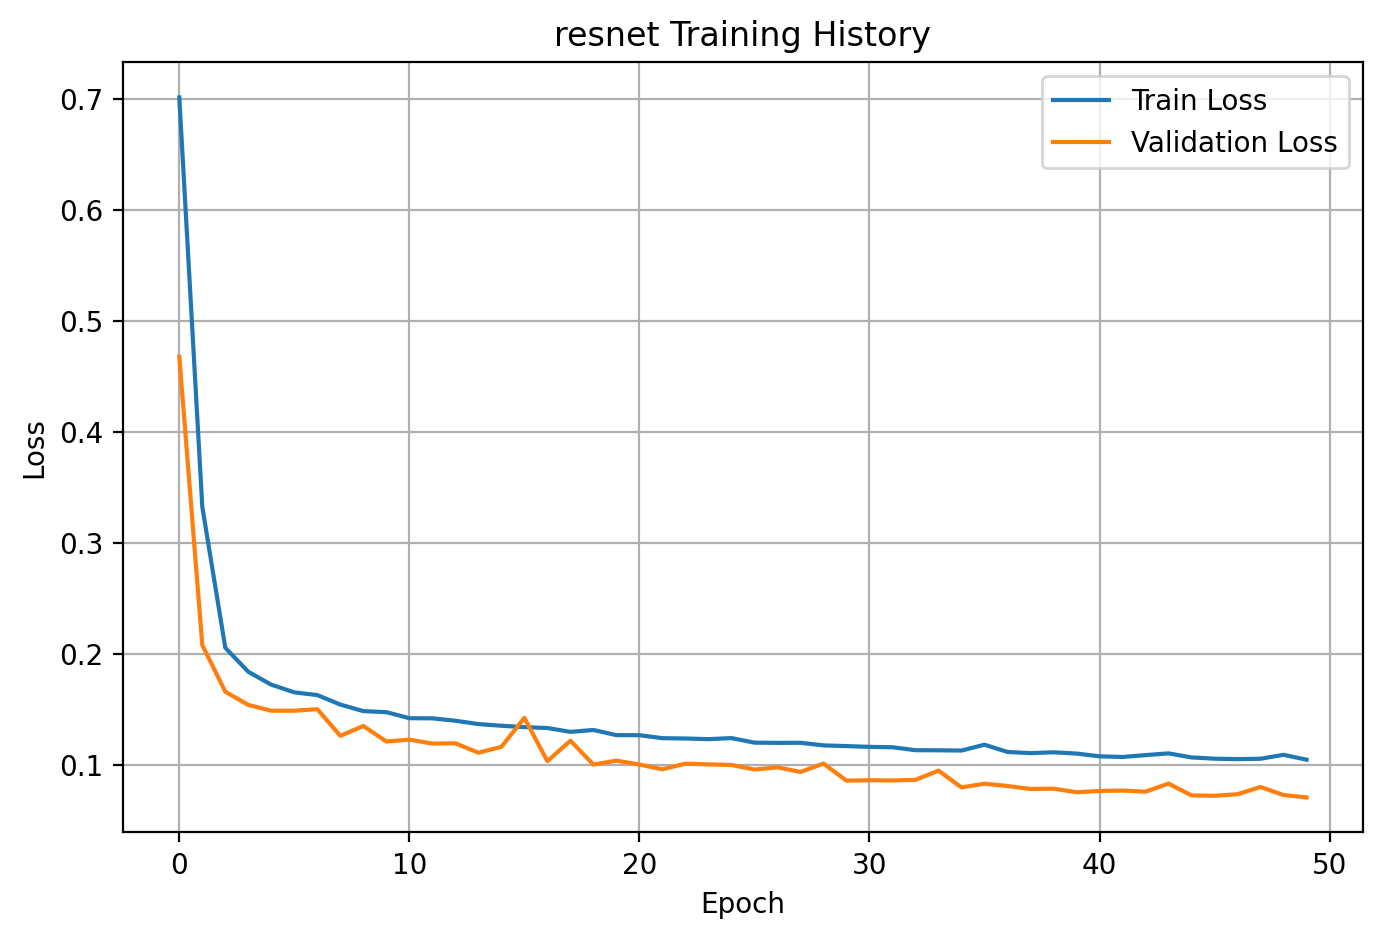

GPU logger was not initialized.
Copied to best model directory
Training complete!


In [8]:
####################
## DOWNSCALING WS ##
####################

var_list = ['WS']
pred_var_list = ['PBLH']

for var in var_list:
    for pred_var in pred_var_list:
        # High resolution (uWRF) data
        var_hr_train = uwrf_train[var]
        var_hr_val = uwrf_val[var]
        var_hr_test = uwrf_test[var]

        pred_var_hr_train = uwrf_train[pred_var]
        pred_var_hr_val = uwrf_val[pred_var]
        pred_var_hr_test = uwrf_test[pred_var]

        # Low resolution (NAM) data
        var_lr_train = nam_train[var]
        var_lr_val = nam_val[var]
        var_lr_test = nam_test[var]

        pred_var_lr_train = nam_train[pred_var]
        pred_var_lr_val = nam_val[pred_var]
        pred_var_lr_test = nam_test[pred_var]

        # Normalize
        var_scaler_train = dds.TorchStandardScaler(axis=None)
        var_scaler_train.fit(var_hr_train)

        pred_var_scaler_train = dds.TorchStandardScaler(axis=None)
        pred_var_scaler_train.fit(pred_var_hr_train)

        # High resolution (targets)
        y_train = var_scaler_train.transform(var_hr_train)
        y_val = var_scaler_train.transform(var_hr_val)
        y_test = var_scaler_train.transform(var_hr_test)

        y_z_train = pred_var_scaler_train.transform(pred_var_hr_train)
        y_z_val = pred_var_scaler_train.transform(pred_var_hr_val)
        y_z_test = pred_var_scaler_train.transform(pred_var_hr_test)

        # Low resolution (inputs)
        x_train = var_scaler_train.transform(var_lr_train)
        x_val = var_scaler_train.transform(var_lr_val)
        x_test = var_scaler_train.transform(var_lr_test)

        x_z_train = pred_var_scaler_train.transform(pred_var_lr_train)
        x_z_val = pred_var_scaler_train.transform(pred_var_lr_val)
        x_z_test = pred_var_scaler_train.transform(pred_var_lr_test)


        y_train = np.expand_dims(y_train, axis=1)
        y_val = np.expand_dims(y_val, axis=1)
        y_test = np.expand_dims(y_test, axis=1)

        y_z_train = np.expand_dims(y_z_train, axis=1)
        y_z_val = np.expand_dims(y_z_val, axis=1)
        y_z_test = np.expand_dims(y_z_test, axis=1)

        x_train = np.expand_dims(x_train, axis=1)
        x_val = np.expand_dims(x_val, axis=1)
        x_test = np.expand_dims(x_test, axis=1)

        x_z_train = np.expand_dims(x_z_train, axis=1)
        x_z_val = np.expand_dims(x_z_val, axis=1)
        x_z_test = np.expand_dims(x_z_test, axis=1)
        
        pred_var_train = [y_z_train]
        pred_var_val = [y_z_val]
        pred_var_test = [y_z_test]
        
        # Paths and file setup
        best_model_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Best-Model"
        other_models_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Other-Models"
        csv_file = f"/home/gvaillant1/downscaling/results/{var}_torch_model_results.csv"
        results = pd.read_csv(csv_file) if os.path.exists(csv_file) else pd.DataFrame()

        # Model uniqueness tracking
        existing_model_ids = set()
        if not results.empty:
            for _, row in results.iterrows():
                model_id_row = (
                    row["Downscaled Variable"],
                    row["Predictor"],
                    row["Backbone"],
                    str(row["Filters"]),
                    str(row["Blocks"]),
                    str(row["Learning Rate"]),
                    row["Interpolation Method"],
                    row["Upsampling Method"],
                    row["Batch Size"],
                    str(row["Epochs"]),
                    row["Loss Function"],
                    str(row["Early Stopping"]),
                    str(row["Conv Block"]),
                    str(row["Device"])
                )
                existing_model_ids.add(model_id_row)

        # Loss tracking for early stopping
        min_losses = {}
        if not results.empty:
            for loss_fn in results['Loss Function'].unique():
                vals = results[results['Loss Function'] == loss_fn]['Test Loss'].astype(float)
                if not vals.empty:
                    min_losses[loss_fn] = vals.min()

        for backbone in ['resnet']:
            for filters in [8]:
                for blocks in [8]:
                    for epoch in [50]:
                        ARCH_PARAMS = dict(
                            n_filters=filters,
                            n_blocks=blocks,
                            normalization=None,
                            dropout_rate=0.5,
                            dropout_variant='spatial',
                            attention=False,
                            activation='relu',
                            localcon_layer=True
                        )

                        print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")

                        trainer = dds.TorchSupervisedTrainer(
                            backbone=backbone,
                            upsampling='spc',
                            data_train=y_train,
                            data_val=y_val,
                            data_test=y_test,
                            scale=3,
                            predictors_train=pred_var_train,
                            predictors_val=pred_var_val,
                            predictors_test=pred_var_test,
                            interpolation='inter_area',
                            batch_size=32,
                            loss='mae',
                            epochs=epoch,
                            steps_per_epoch=None,
                            validation_steps=None,
                            test_steps=None,
                            learning_rate=1e-3,
                            lr_decay_after=1e4,
                            early_stopping=True,
                            patience=6,
                            min_delta=0,
                            save=False,
                            save_bestmodel=False,
                            save_path=other_models_path,
                            show_plot=True,
                            verbose=True,
                            device='CPU',
                            **ARCH_PARAMS)

                        model_id = (
                            var,
                            "NULL" if trainer.predictors_train is None else pred_var,
                            backbone,
                            str(filters),
                            str(blocks),
                            str(trainer.learning_rate),
                            trainer.interpolation,
                            trainer.upsampling,
                            trainer.batch_size,
                            str(trainer.epochs),
                            trainer.loss,
                            str(trainer.early_stopping),
                            str(ARCH_PARAMS["localcon_layer"]),
                            str(trainer.device)
                        )

                        if model_id in existing_model_ids:
                            print("Match found! Skipping training for:", model_id)
                            continue

                        trainer.run()

                        val_loss = trainer.val_loss if hasattr(trainer, "val_loss") else float("inf")
                        training_runtime = trainer.training_runtime if hasattr(trainer, "training_runtime") else "NULL"

                        # Always save to "Other Models" first
                        os.makedirs(other_models_path, exist_ok=True)
                        model_filename = f"{var.lower()}_model.pth"
                        model_file_path = os.path.join(other_models_path, model_filename)
                        pt.save(trainer.model.state_dict(), model_file_path)

                        # If this is the best model so far (per loss function), copy to "Best Model"
                        if trainer.loss not in min_losses or val_loss < min_losses[trainer.loss]:
                            min_losses[trainer.loss] = val_loss
                            os.makedirs(best_model_path, exist_ok=True)
                            shutil.copy(model_file_path, os.path.join(best_model_path, model_filename))
                            model_save_path = best_model_path
                            print("Copied to best model directory")
                        else:
                            model_save_path = other_models_path

                        # Log result
                        new_result = pd.DataFrame([[
                            var,
                            "NULL" if trainer.predictors_train is None else pred_var,
                            round(val_loss, 4),
                            backbone,
                            filters,
                            blocks,
                            trainer.epochs,
                            sum(p.numel() for p in trainer.model.parameters() if p.requires_grad),
                            trainer.upsampling,
                            trainer.interpolation,
                            trainer.batch_size,
                            trainer.learning_rate,
                            trainer.loss,
                            trainer.early_stopping,
                            training_runtime,
                            model_save_path,
                            ARCH_PARAMS["localcon_layer"],
                            trainer.device
                        ]], columns=[
                            "Downscaled Variable", "Predictor", "Test Loss",
                            "Backbone", "Filters", "Blocks",
                            "Epochs", "Parameters", "Upsampling Method",
                            "Interpolation Method", "Batch Size", "Learning Rate",
                            "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"
                        ])

                        # Append the new result to CSV immediately
                        if os.path.exists(csv_file):
                            new_result.to_csv(csv_file, mode='a', index=False, header=False)
                        else:
                            new_result.to_csv(csv_file, mode='w', index=False, header=True)
                        
                        # Reload CSV so next model can compare against updated results
                        results = pd.read_csv(csv_file)

        print("Training complete!")
